# 04.2 — Origin Classification with ModernBERT (2024)

This notebook adds **ModernBERT-base** (`answerdotai/ModernBERT-base`, Dec 2024) to the origin classification comparison. ModernBERT is a drop-in replacement for BERT/RoBERTa trained on 2024-era data with architectural improvements (rotary position embeddings, flash attention, longer context).

**Setup is identical to 04.1** (same seed, same filtering, same 70/15/15 split) for apples-to-apples comparison against fine-tuned RoBERTa.

**Prior results to beat:**
- TF-IDF baseline: Macro-F1 0.144
- RoBERTa fine-tuned: Macro-F1 0.186

**Requirements:** `transformers >= 4.48.0` (run `pip install --upgrade transformers` if you hit a `ModernBertModel not found` error).

In [1]:
import os
import re
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support, classification_report,
    balanced_accuracy_score, confusion_matrix, ConfusionMatrixDisplay, f1_score,
)
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from transformers import (
    AutoModelForSequenceClassification, AutoTokenizer, DataCollatorWithPadding,
    EarlyStoppingCallback, Trainer, TrainingArguments,
)
from transformers.utils.notebook import NotebookProgressCallback

In [2]:
RANDOM_STATE = 42
MIN_SAMPLES_PER_CLASS = 100
MODEL_CHECKPOINT = 'answerdotai/ModernBERT-base'
TEXT_COLUMN = 'text_basic_plus_aspects'
MAX_LENGTH = 256  # same as 04.1 for fair comparison; ModernBERT supports up to 8192

# Training config — matches 04.1 exactly
NUM_TRAIN_EPOCHS = 12
TRAIN_BATCH_SIZE = 16
EVAL_BATCH_SIZE = 32
GRAD_ACCUM_STEPS = 2  # effective batch = 32
WEIGHT_DECAY = 0.01
WARMUP_RATIO = 0.06
EARLY_STOP_PATIENCE = 3
USE_FP16 = True

LR_SWEEP = [1e-5, 2e-5, 3e-5, 5e-5]

OUTPUT_DIR_ROOT = 'artifacts/origin_finetuning_modernbert'
os.makedirs(OUTPUT_DIR_ROOT, exist_ok=True)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', DEVICE)

def set_seed(seed: int):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(RANDOM_STATE)

Device: cuda


## Load & preprocess (identical to 04.1)

In [3]:
df = pd.read_csv('Data/final_coffee_reviews.csv')

def minimal_raw_text(text):
    text = '' if pd.isna(text) else str(text)
    return re.sub(r'\s+', ' ', text).strip().lower()

def normalize_text(text):
    text = minimal_raw_text(text)
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    return re.sub(r'\s+', ' ', text).strip()

df['text_raw_minimal'] = df['Blind Assessment'].fillna('').map(minimal_raw_text)
df['text_basic'] = df['Blind Assessment'].fillna('').map(normalize_text)

for col in ['aroma_text', 'flavor_text', 'acidity_text', 'body_text', 'combined_text']:
    if col not in df.columns:
        df[col] = ''
    df[col] = df[col].fillna('').astype(str)

df['aspect_text_combined'] = df['combined_text'].map(normalize_text)
df['text_basic_plus_aspects'] = (
    df['text_basic'].fillna('') + ' ' + df['aspect_text_combined'].fillna('')
).str.replace(r'\s+', ' ', regex=True).str.strip()

df['origin_country'] = df['Country'].astype('string').str.strip()
df['origin_country'] = df['origin_country'].replace('', pd.NA)

work = df[(df['text_raw_minimal'].str.len() >= 30) & (df['origin_country'].notna())].copy()
counts = work['origin_country'].value_counts()
valid_classes = counts[counts >= MIN_SAMPLES_PER_CLASS].index
work = work[work['origin_country'].isin(valid_classes)].copy().reset_index(drop=True)

print('Rows:', len(work), 'Classes:', work['origin_country'].nunique())

Rows: 6820 Classes: 15


In [4]:
y = work['origin_country']
row_idx = work.index

train_idx, temp_idx, y_train, y_temp = train_test_split(
    row_idx, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y
)
val_idx, test_idx, y_val, y_test = train_test_split(
    temp_idx, y_temp, test_size=0.50, random_state=RANDOM_STATE, stratify=y_temp
)

print('Train/Val/Test:', len(train_idx), len(val_idx), len(test_idx))

label_names = sorted(work['origin_country'].unique())
label2id = {label: idx for idx, label in enumerate(label_names)}
id2label = {idx: label for label, idx in label2id.items()}

train_texts = work.loc[train_idx, TEXT_COLUMN].fillna('').tolist()
val_texts   = work.loc[val_idx,   TEXT_COLUMN].fillna('').tolist()
test_texts  = work.loc[test_idx,  TEXT_COLUMN].fillna('').tolist()

train_labels = work.loc[train_idx, 'origin_country'].map(label2id).tolist()
val_labels   = work.loc[val_idx,   'origin_country'].map(label2id).tolist()
test_labels  = work.loc[test_idx,  'origin_country'].map(label2id).tolist()

class_weights_np = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(len(label_names)),
    y=np.array(train_labels),
)
class_weights_tensor = torch.tensor(class_weights_np, dtype=torch.float)

Train/Val/Test: 4774 1023 1023


In [5]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_CHECKPOINT)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

class CoffeeOriginDataset(torch.utils.data.Dataset):
    def __init__(self, texts, labels, tokenizer, max_length):
        self.encodings = tokenizer(texts, truncation=True, max_length=max_length, padding=False)
        self.labels = labels
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

train_dataset = CoffeeOriginDataset(train_texts, train_labels, tokenizer, MAX_LENGTH)
val_dataset   = CoffeeOriginDataset(val_texts,   val_labels,   tokenizer, MAX_LENGTH)
test_dataset  = CoffeeOriginDataset(test_texts,  test_labels,  tokenizer, MAX_LENGTH)
print('Datasets ready.')

Datasets ready.


In [6]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='macro', zero_division=0)
    return {
        'accuracy': accuracy_score(labels, preds),
        'balanced_accuracy': balanced_accuracy_score(labels, preds),
        'precision_macro': precision,
        'recall_macro': recall,
        'f1_macro': f1,
    }

class WeightedTrainer(Trainer):
    def __init__(self, class_weights=None, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.pop('labels')
        outputs = model(**inputs)
        logits = outputs.get('logits')
        loss_fct = torch.nn.CrossEntropyLoss(weight=self.class_weights.to(logits.device))
        loss = loss_fct(logits, labels)
        return (loss, outputs) if return_outputs else loss

def build_training_args(output_dir: str, learning_rate: float):
    return TrainingArguments(
        output_dir=output_dir,
        learning_rate=learning_rate,
        per_device_train_batch_size=TRAIN_BATCH_SIZE,
        per_device_eval_batch_size=EVAL_BATCH_SIZE,
        gradient_accumulation_steps=GRAD_ACCUM_STEPS,
        num_train_epochs=NUM_TRAIN_EPOCHS,
        weight_decay=WEIGHT_DECAY,
        warmup_ratio=WARMUP_RATIO,
        eval_strategy='epoch',
        save_strategy='epoch',
        save_total_limit=1,
        load_best_model_at_end=True,
        metric_for_best_model='f1_macro',
        greater_is_better=True,
        logging_strategy='epoch',
        disable_tqdm=True,
        report_to='none',
        fp16=USE_FP16 and torch.cuda.is_available(),
        seed=RANDOM_STATE,
    )

def run_one(learning_rate: float, use_class_weights: bool, tag: str):
    set_seed(RANDOM_STATE)
    out_dir = os.path.join(OUTPUT_DIR_ROOT, tag)
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_CHECKPOINT,
        num_labels=len(label_names),
        id2label=id2label,
        label2id=label2id,
    )
    args = build_training_args(out_dir, learning_rate)
    trainer_cls = WeightedTrainer if use_class_weights else Trainer
    extra = dict(class_weights=class_weights_tensor) if use_class_weights else {}
    trainer = trainer_cls(
        model=model, args=args,
        train_dataset=train_dataset, eval_dataset=val_dataset,
        processing_class=tokenizer, data_collator=data_collator,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=EARLY_STOP_PATIENCE)],
        **extra,
    )
    try: trainer.remove_callback(NotebookProgressCallback)
    except Exception: pass
    print(f'\n=== Training {tag} | lr={learning_rate} | weighted={use_class_weights} ===')
    train_out = trainer.train()
    val_metrics = trainer.evaluate(eval_dataset=val_dataset)
    test_metrics = trainer.evaluate(eval_dataset=test_dataset, metric_key_prefix='test')
    return trainer, train_out, val_metrics, test_metrics

## Step 1 — LR sweep (plain cross-entropy)

Expected runtime: ~3–5 min per LR × 4 LRs ≈ 15–20 min total.

In [7]:
sweep_results = []
for lr in LR_SWEEP:
    tag = f'plainCE_lr{lr:.0e}'
    _, train_out, val_m, test_m = run_one(lr, use_class_weights=False, tag=tag)
    sweep_results.append({
        'tag': tag,
        'lr': lr,
        'final_train_loss': train_out.training_loss,
        'val_f1_macro': val_m['eval_f1_macro'],
        'val_balanced_acc': val_m['eval_balanced_accuracy'],
        'val_accuracy': val_m['eval_accuracy'],
        'test_f1_macro': test_m['test_f1_macro'],
        'test_balanced_acc': test_m['test_balanced_accuracy'],
        'test_accuracy': test_m['test_accuracy'],
    })

sweep_df = pd.DataFrame(sweep_results).sort_values('val_f1_macro', ascending=False)
sweep_df

Loading weights:   0%|          | 0/136 [00:00<?, ?it/s]

ModernBertForSequenceClassification LOAD REPORT from: answerdotai/ModernBERT-base
Key               | Status     | Details
------------------+------------+--------
decoder.bias      | UNEXPECTED |        
classifier.weight | MISSING    |        
classifier.bias   | MISSING    |        

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': None, 'bos_token_id': None}.



=== Training plainCE_lr1e-05 | lr=1e-05 | weighted=False ===
{'loss': '4.79', 'grad_norm': '17.33', 'learning_rate': '9.775e-06', 'epoch': '1'}
{'eval_loss': '2.267', 'eval_accuracy': '0.2933', 'eval_balanced_accuracy': '0.06735', 'eval_precision_macro': '0.02895', 'eval_recall_macro': '0.06735', 'eval_f1_macro': '0.03288', 'eval_runtime': '2.65', 'eval_samples_per_second': '386', 'eval_steps_per_second': '12.07', 'epoch': '1'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'loss': '4.344', 'grad_norm': '16.21', 'learning_rate': '8.889e-06', 'epoch': '2'}
{'eval_loss': '2.178', 'eval_accuracy': '0.3343', 'eval_balanced_accuracy': '0.1063', 'eval_precision_macro': '0.1335', 'eval_recall_macro': '0.1063', 'eval_f1_macro': '0.08655', 'eval_runtime': '2.952', 'eval_samples_per_second': '346.6', 'eval_steps_per_second': '10.84', 'epoch': '2'}


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'train_runtime': '470.1', 'train_samples_per_second': '121.9', 'train_steps_per_second': '3.829', 'train_loss': '1.657', 'epoch': '10'}
{'eval_loss': '4.186', 'eval_accuracy': '0.3441', 'eval_balanced_accuracy': '0.1866', 'eval_precision_macro': '0.2304', 'eval_recall_macro': '0.1866', 'eval_f1_macro': '0.1903', 'eval_runtime': '3.061', 'eval_samples_per_second': '334.3', 'eval_steps_per_second': '10.46', 'epoch': '10'}


early stopping required metric_for_best_model, but did not find eval_f1_macro so early stopping is disabled


{'test_loss': '3.722', 'test_accuracy': '0.3597', 'test_balanced_accuracy': '0.1875', 'test_precision_macro': '0.2097', 'test_recall_macro': '0.1875', 'test_f1_macro': '0.1873', 'test_runtime': '2.864', 'test_samples_per_second': '357.2', 'test_steps_per_second': '11.17', 'epoch': '10'}


,tag,lr,final_train_loss,val_f1_macro,val_balanced_acc,val_accuracy,test_f1_macro,test_balanced_acc,test_accuracy
3,plainCE_lr5e-05,0.00005,1.656691,0.190289,0.186598,0.344086,0.187337,0.187491,0.359726
2,plainCE_lr3e-05,0.00003,1.717771,0.179909,0.179680,0.314761,0.193360,0.191357,0.334311
1,plainCE_lr2e-05,0.00002,1.829541,0.178741,0.177415,0.308895,0.168318,0.170758,0.329423
0,plainCE_lr1e-05,0.00001,2.518088,0.170178,0.169243,0.314761,0.142324,0.150554,0.314761


In [8]:
best_row = sweep_df.iloc[0]
BEST_LR = float(best_row['lr'])
print(f'Best LR: {BEST_LR}')
print(f'  val macro-F1:  {best_row["val_f1_macro"]:.4f}')
print(f'  test macro-F1: {best_row["test_f1_macro"]:.4f}')
print(f'  test bal-acc:  {best_row["test_balanced_acc"]:.4f}')
print()
print('vs TF-IDF baseline:     0.144')
print('vs RoBERTa fine-tuned:  0.186')

Best LR: 5e-05
  val macro-F1:  0.1903
  test macro-F1: 0.1873
  test bal-acc:  0.1875

vs TF-IDF baseline:     0.144
vs RoBERTa fine-tuned:  0.186


## Step 2 — Weighted CE at best LR (and at lr=1e-5 as safety)

In [9]:
weighted_results = []
weighted_lrs = sorted({1e-5, BEST_LR})  # always include 1e-5, plus best

for lr in weighted_lrs:
    tag = f'weightedCE_lr{lr:.0e}'
    _, train_out, val_m, test_m = run_one(lr, use_class_weights=True, tag=tag)
    weighted_results.append({
        'tag': tag,
        'lr': lr,
        'final_train_loss': train_out.training_loss,
        'val_f1_macro': val_m['eval_f1_macro'],
        'val_balanced_acc': val_m['eval_balanced_accuracy'],
        'val_accuracy': val_m['eval_accuracy'],
        'test_f1_macro': test_m['test_f1_macro'],
        'test_balanced_acc': test_m['test_balanced_accuracy'],
        'test_accuracy': test_m['test_accuracy'],
    })

weighted_df = pd.DataFrame(weighted_results).sort_values('val_f1_macro', ascending=False)
weighted_df

Loading weights:   0%|          | 0/136 [00:00<?, ?it/s]

ModernBertForSequenceClassification LOAD REPORT from: answerdotai/ModernBERT-base
Key               | Status     | Details
------------------+------------+--------
decoder.bias      | UNEXPECTED |        
classifier.weight | MISSING    |        
classifier.bias   | MISSING    |        

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': None, 'bos_token_id': None}.



=== Training weightedCE_lr1e-05 | lr=1e-05 | weighted=True ===
{'loss': '5.503', 'grad_norm': '14.56', 'learning_rate': '9.781e-06', 'epoch': '1'}
{'eval_loss': '2.704', 'eval_accuracy': '0.1241', 'eval_balanced_accuracy': '0.1043', 'eval_precision_macro': '0.1345', 'eval_recall_macro': '0.1043', 'eval_f1_macro': '0.06267', 'eval_runtime': '2.679', 'eval_samples_per_second': '381.9', 'eval_steps_per_second': '11.95', 'epoch': '1'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'loss': '5.263', 'grad_norm': '14.02', 'learning_rate': '8.895e-06', 'epoch': '2'}
{'eval_loss': '2.636', 'eval_accuracy': '0.09677', 'eval_balanced_accuracy': '0.1363', 'eval_precision_macro': '0.1788', 'eval_recall_macro': '0.1363', 'eval_f1_macro': '0.06825', 'eval_runtime': '2.702', 'eval_samples_per_second': '378.6', 'eval_steps_per_second': '11.84', 'epoch': '2'}


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'train_runtime': '325.8', 'train_samples_per_second': '175.8', 'train_steps_per_second': '5.524', 'train_loss': '3.415', 'epoch': '7'}
{'eval_loss': '2.773', 'eval_accuracy': '0.2717', 'eval_balanced_accuracy': '0.1921', 'eval_precision_macro': '0.1916', 'eval_recall_macro': '0.1921', 'eval_f1_macro': '0.1746', 'eval_runtime': '3.143', 'eval_samples_per_second': '325.5', 'eval_steps_per_second': '10.18', 'epoch': '7'}


early stopping required metric_for_best_model, but did not find eval_f1_macro so early stopping is disabled


{'test_loss': '2.758', 'test_accuracy': '0.2727', 'test_balanced_accuracy': '0.1964', 'test_precision_macro': '0.1954', 'test_recall_macro': '0.1964', 'test_f1_macro': '0.1736', 'test_runtime': '3.015', 'test_samples_per_second': '339.3', 'test_steps_per_second': '10.61', 'epoch': '7'}


,tag,lr,final_train_loss,val_f1_macro,val_balanced_acc,val_accuracy,test_f1_macro,test_balanced_acc,test_accuracy
1,weightedCE_lr5e-05,0.00005,3.414594,0.174606,0.192100,0.271750,0.173566,0.196422,0.272727
0,weightedCE_lr1e-05,0.00001,3.900781,0.140334,0.159374,0.223851,0.133450,0.150621,0.209189


## Step 3 — Per-class report + confusion matrix for the winning config

In [10]:
all_runs = pd.concat([sweep_df, weighted_df], ignore_index=True)
winner = all_runs.sort_values('val_f1_macro', ascending=False).iloc[0]
print(f'Winning config: {winner["tag"]} (val F1-macro = {winner["val_f1_macro"]:.4f})')

# Re-train the winner to get a trainer object for predictions
is_weighted = 'weighted' in winner['tag']
winning_trainer, _, _, _ = run_one(
    float(winner['lr']), use_class_weights=is_weighted, tag=f'winner_rerun_{winner["tag"]}'
)

test_pred_output = winning_trainer.predict(test_dataset)
test_pred_ids = np.argmax(test_pred_output.predictions, axis=1)
test_true_labels = [id2label[i] for i in test_labels]
test_pred_labels = [id2label[i] for i in test_pred_ids]

print('\n== Test headline ==')
print(f'Macro-F1:          {f1_score(test_true_labels, test_pred_labels, average="macro", zero_division=0):.4f}')
print(f'Balanced Accuracy: {balanced_accuracy_score(test_true_labels, test_pred_labels):.4f}')
print(f'Accuracy:          {accuracy_score(test_true_labels, test_pred_labels):.4f}')

class_order = work['origin_country'].value_counts().index.tolist()
print('\nTest per-class report:')
print(classification_report(test_true_labels, test_pred_labels, labels=class_order, zero_division=0, digits=3))

Winning config: plainCE_lr5e-05 (val F1-macro = 0.1903)


Loading weights:   0%|          | 0/136 [00:00<?, ?it/s]

ModernBertForSequenceClassification LOAD REPORT from: answerdotai/ModernBERT-base
Key               | Status     | Details
------------------+------------+--------
decoder.bias      | UNEXPECTED |        
classifier.weight | MISSING    |        
classifier.bias   | MISSING    |        

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': None, 'bos_token_id': None}.



=== Training winner_rerun_plainCE_lr5e-05 | lr=5e-05 | weighted=False ===
{'loss': '4.658', 'grad_norm': '11.84', 'learning_rate': '4.885e-05', 'epoch': '1'}
{'eval_loss': '2.203', 'eval_accuracy': '0.3421', 'eval_balanced_accuracy': '0.1083', 'eval_precision_macro': '0.07874', 'eval_recall_macro': '0.1083', 'eval_f1_macro': '0.07804', 'eval_runtime': '2.66', 'eval_samples_per_second': '384.6', 'eval_steps_per_second': '12.03', 'epoch': '1'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

{'loss': '0.0003173', 'grad_norm': '0.02302', 'learning_rate': '2.069e-07', 'epoch': '12'}
{'eval_loss': '4.344', 'eval_accuracy': '0.347', 'eval_balanced_accuracy': '0.1827', 'eval_precision_macro': '0.1904', 'eval_recall_macro': '0.1827', 'eval_f1_macro': '0.1827', 'eval_runtime': '2.84', 'eval_samples_per_second': '360.3', 'eval_steps_per_second': '11.27', 'epoch': '12'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'train_runtime': '546.3', 'train_samples_per_second': '104.9', 'train_steps_per_second': '3.295', 'train_loss': '1.51', 'epoch': '12'}
{'eval_loss': '4.272', 'eval_accuracy': '0.349', 'eval_balanced_accuracy': '0.1882', 'eval_precision_macro': '0.205', 'eval_recall_macro': '0.1882', 'eval_f1_macro': '0.1919', 'eval_runtime': '2.816', 'eval_samples_per_second': '363.3', 'eval_steps_per_second': '11.36', 'epoch': '12'}


early stopping required metric_for_best_model, but did not find eval_f1_macro so early stopping is disabled


{'test_loss': '3.908', 'test_accuracy': '0.3627', 'test_balanced_accuracy': '0.1831', 'test_precision_macro': '0.1968', 'test_recall_macro': '0.1831', 'test_f1_macro': '0.1842', 'test_runtime': '2.812', 'test_samples_per_second': '363.8', 'test_steps_per_second': '11.38', 'epoch': '12'}

== Test headline ==
Macro-F1:          0.1842
Balanced Accuracy: 0.1831
Accuracy:          0.3627

Test per-class report:
               precision    recall  f1-score   support

     Ethiopia      0.465     0.642     0.539       299
     Colombia      0.280     0.358     0.315       148
        Kenya      0.552     0.505     0.527       105
    Guatemala      0.280     0.250     0.264        84
    Indonesia      0.492     0.441     0.465        68
   Costa Rica      0.040     0.018     0.025        56
       Panama      0.194     0.113     0.143        53
United States      0.190     0.178     0.184        45
  El Salvador      0.069     0.056     0.062        36
       Brazil      0.190     0.133    

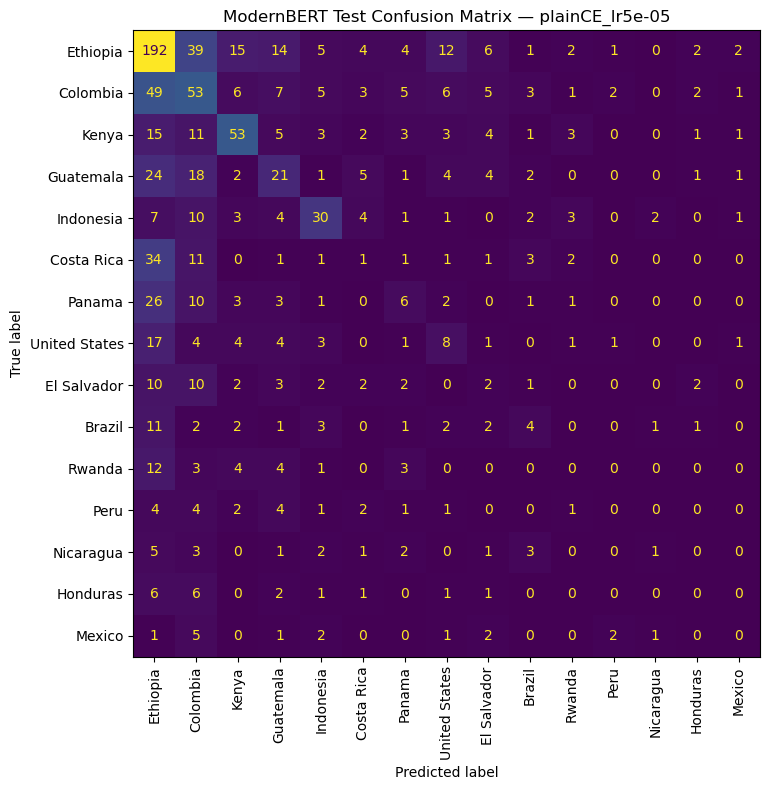

In [11]:
cm = confusion_matrix(test_true_labels, test_pred_labels, labels=class_order)
fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_order).plot(
    ax=ax, xticks_rotation=90, colorbar=False,
)
plt.title(f'ModernBERT Test Confusion Matrix — {winner["tag"]}')
plt.tight_layout()
plt.show()

In [12]:
with open(os.path.join(OUTPUT_DIR_ROOT, 'all_results.json'), 'w') as f:
    json.dump({
        'model': MODEL_CHECKPOINT,
        'plain_ce_sweep': sweep_results,
        'weighted_ce': weighted_results,
        'winner': winner['tag'],
        'tfidf_baseline_f1_macro': 0.144,
        'roberta_best_f1_macro': 0.186,
    }, f, indent=2)
print('Saved all_results.json')

Saved all_results.json


## Interpretation

- If ModernBERT > RoBERTa: supports the claim that 2024 architecture improvements help on this domain. Worth reporting as the main classification result.
- If ModernBERT ≈ RoBERTa: both are competitive — report both and note the small gap.
- If ModernBERT < RoBERTa: interesting negative result; may indicate RoBERTa's pretraining corpus aligns better with coffee review vocabulary. Worth discussing briefly.

In all cases, keep both in your paper's results table — don't throw away the RoBERTa number.